# X-Set Enrichment Analysis (XSEA; c.f. ABAnnotate)

So far, we've been computing colocalization values between a brain map and individual reference maps — one correlation per receptor or gene. But sometimes we don't care about individual maps; we want to know whether the brain pattern of interest is broadly associated with a *group* of maps — say, all serotonin receptors, or all genes expressed in excitatory neurons.

This is the idea behind **X-Set Enrichment Analysis (XSEA)**. The concept is closely related to Gene Set Enrichment Analysis (GSEA) in transcriptomics, adapted for brain maps.

The concept of XSEA used here was first implemented in the MATLAB toolbox [**ABAnnotate**](https://github.com/leondlotter/ABAnnotate), a predecessor of NiSpace. If you've used ABAnnotate, you'll find the concepts familiar.

## The idea

Given a brain map and a set of reference maps (e.g., all receptor maps for serotonin), XSEA computes:

1. The mean colocalization between the brain map and all maps in the set.
2. A p-value asking: is this mean colocalization higher than expected when the brain map is replaced by a spatially-constrained random map?

The result is one statistic per *set*, not per individual map.

## A note on null models

There are two natural null hypotheses for XSEA:

1. **Permute the input map** (default): generate surrogate maps of the brain map and recompute mean colocalizations. This tests whether the observed mean is higher than expected under spatial randomness.
2. **Permute the sets**: randomly sample sets from a larger background population of maps and ask whether the observed set mean is higher than random sets.

Ben Fulcher et al. (2021, *Nature Communications*) showed that random set sampling can inflate false positives when maps within a set are highly co-expressed (correlated). NiSpace therefore defaults to map permutation, following the approach of ABAnnotate. Pass `permute_sets=True` to switch to set permutation if needed. However, this is currently not recommended. In the future, we will implement within-set correlation-matched set resampling, which can address this issue.

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd

In [2]:
from nispace.datasets import fetch_reference, fetch_example
from nispace.io import load_img
from nispace.api import NiSpace

## Dataset setup

We'll run XSEA on the pain map against mRNA gene expression data, testing whether pain-related brain activation broadly aligns with the expression of particular cell types.

The mRNA reference dataset is derived from the Allen Human Brain Atlas (AHBA) and provides mean gene expression per brain region for thousands of genes, organized into sets such as cell type markers.

In [3]:
# pain map (NeuroQuery meta-analytic z-map)
pain_map = load_img("neuroquery/pain.nii.gz")

# mRNA reference: cell type marker sets (Lake et al 2016)
# parcellation: Schaefer100+TianS1 (low resolution to match coarse ABA data sampling)
mrna = fetch_reference(
    "mrna",
    parcellation="Schaefer100TianS1",
    collection="CellTypesPsychEncodeTPM",
    print_references=False
)
print(f"mRNA data: {mrna.shape[0]} genes across {mrna.index.get_level_values('set').nunique()} sets x {mrna.shape[1]} parcels")
print(f"Set names: {list(mrna.index.get_level_values('set').unique())}")
mrna.head(3)

INFO | 01/06/26 12:43:52 | nispace.datasets: Loading mrna maps.


INFO | 01/06/26 12:43:52 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.


INFO | 01/06/26 12:43:52 | nispace.datasets: Filtering maps by collection.


INFO | 01/06/26 12:43:52 | nispace.datasets: Loading and inner-merging data parcellated with 'Schaefer100Parcels7Networks' and 'TianS1'


mRNA data: 465 genes across 24 sets x 116 parcels
Set names: ['Ex1 CortProject (L2/3)', 'Ex2 Granule (L3/4)', 'Ex3 Granule (L4)', 'Ex4 SubcortProject (L4)', 'Ex5 SubcortProject (L4-6)', 'Ex6 SubcortProject (L5-6)', 'Ex7 Corticothalamic', 'Ex8 Corticothalamic (L6)', 'In1 VIP+RELN+NDNF+ (L1/2)', 'In2 VIP+RELN-NDNF- (L6)', 'In3 VIP+RELN+NDNF- (L6)', 'In4 VIP-RELN+NDNF+ (L1-3)', 'In5 CCK+NOS1+CALB2+ (L2/3)', 'In6 PVALB+CRHBP+ (L4/5)', 'In7 SST+CALB1+NPY+ (L5/6)', 'In8 SST+NOS1+ (L6)', 'Astrocyte', 'Endothelial', 'Developing-quiescent', 'Developing-replicating', 'Microglia', 'Other Neurons', 'OPC', 'Oligodendrocyte']


hemi-L_div-Vis_lab-1  hemi-L_div-Vis_lab-2  \
set                    map                                                   
Ex1 CortProject (L2/3) CAMK2A               0.842136              0.826765   
                       CCDC88C              0.490978              0.415965   
                       CDH9                 0.742186              0.618615   

                                hemi-L_div-Vis_lab-3  hemi-L_div-Vis_lab-4  \
set                    map                                                   
Ex1 CortProject (L2/3) CAMK2A               0.826967              0.827184   
                       CCDC88C              0.401705              0.323039   
                       CDH9                 0.623595              0.567650   

                                hemi-L_div-Vis_lab-5  hemi-L_div-Vis_lab-6  \
set                    map                                                   
Ex1 CortProject (L2/3) CAMK2A               0.817241              0.822723   
                       CCDC88C              0.311288              0.341007   
                       CDH9                 0.546706              0.577347   

                                hemi-L_div-Vis_lab-7  hemi-L_div-Vis_lab-8  \
set                    map                                                   
Ex1 CortProject (L2/3) CAMK2A               0.815382              0.818394   
                       CCDC88C              0.394077              0.361664   
                       CDH9                 0.681953              0.648653   

                                hemi-L_div-Vis_lab-9  hemi-L_div-SomMot_lab-1  \
set                    map                                                      
Ex1 CortProject (L2/3) CAMK2A               0.815004                 0.819051   
                       CCDC88C              0.407064                 0.432452   
                       CDH9                 0.656170                 0.708508   

                                ...  hemi-L_lab-PUT  hemi-L_lab-CAU  \
set                    map      ...                                   
Ex1 CortProject (L2/3) CAMK2A   ...        0.452723        0.571612   
                       CCDC88C  ...        0.784354        0.905244   
                       CDH9     ...        0.483765        0.509307   

                                hemi-R_lab-HIP  hemi-R_lab-AMY  \
set                    map                                       
Ex1 CortProject (L2/3) CAMK2A         0.792884        0.710187   
                       CCDC88C        0.417680        0.772467   
                       CDH9           0.638481        0.786927   

                                hemi-R_lab-pTHA  hemi-R_lab-aTHA  \
set                    map                                         
Ex1 CortProject (L2/3) CAMK2A          0.414296         0.366631   
                       CCDC88C         0.433421         0.556930   
                       CDH9            0.225884         0.266731   

                                hemi-R_lab-NAc  hemi-R_lab-GP  hemi-R_lab-PUT  \
set                    map                                                      
Ex1 CortProject (L2/3) CAMK2A         0.485376       0.288345        0.537562   
                       CCDC88C        0.916510       0.728213        0.748571   
                       CDH9           0.684596       0.402965        0.512751   

                                hemi-R_lab-CAU  
set                    map                      
Ex1 CortProject (L2/3) CAMK2A         0.596598  
                       CCDC88C        0.981271  
                       CDH9           0.539964  

[3 rows x 116 columns]

Notice the two-level MultiIndex: the first level is the cell type group ("set"), the second is the individual gene. The set structure is what XSEA operates on.

## Running XSEA step by step

XSEA is triggered by passing `xsea=True` (or a specific aggregation method) to `colocalize()`. This computes colocalization with each individual map first, then averages within sets.

In [4]:
nsp = NiSpace(
    x=mrna,
    y=pain_map,
    y_labels="Pain",
    parcellation="Schaefer100TianS1",
    seed=42,
    n_proc=4
)
nsp.fit()

# colocalize with XSEA aggregation
# xsea=True computes the mean colocalization within each set
nsp.colocalize("spearman", xsea=True)

# the result has one column per set (not per individual gene)
colocs = nsp.get_colocalizations()
print(f"XSEA colocalizations: {colocs.shape[1]} sets")
print(colocs.T.sort_values(by="Pain", ascending=False))

INFO | 01/06/26 12:43:52 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 01/06/26 12:43:52 | nispace.core.parcellation: Building combined Parcellation 'Schaefer100Parcels7Networks+TianS1' from library.


INFO | 01/06/26 12:43:52 | nispace.core.parcellation:   Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].


INFO | 01/06/26 12:43:52 | nispace.core.parcellation:   Merging 'Schaefer100Parcels7Networks' and 'TianS1' for space 'MNI152NLin2009cAsym'.


INFO | 01/06/26 12:43:52 | nispace.core.parcellation:   Merging 'Schaefer100Parcels7Networks' and 'TianS1' for space 'MNI152NLin6Asym'.


...

INFO | 01/06/26 12:43:57 | nispace.api: Pre-ranking X and Y data.


Colocalizing (spearman, 4 proc):   0%|                                                                   | 0/1 [00:00<?, ?it/s]

Colocalizing (spearman, 4 proc): 100%|█████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2410.52it/s]

INFO | 01/06/26 12:44:00 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


XSEA colocalizations: 24 sets
                                Pain
Microglia                   0.250146
Astrocyte                   0.175766
OPC                         0.168996
In1 VIP+RELN+NDNF+ (L1/2)   0.142336
Endothelial                 0.141804
Ex6 SubcortProject (L5-6)   0.131066
Ex8 Corticothalamic (L6)    0.127390
Oligodendrocyte             0.118138
Developing-replicating      0.105683
Ex7 Corticothalamic         0.087049
Developing-quiescent        0.059943
In2 VIP+RELN-NDNF- (L6)     0.042509
Other Neurons               0.017340
Ex1 CortProject (L2/3)      0.017241
In3 VIP+RELN+NDNF- (L6)     0.011462
In8 SST+NOS1+ (L6)         -0.009339
Ex5 SubcortProject (L4-6)  -0.018907
In6 PVALB+CRHBP+ (L4/5)    -0.019250
Ex2 Granule (L3/4)         -0.024170
In7 SST+CALB1+NPY+ (L5/6)  -0.024495
In5 CCK+NOS1+CALB2+ (L2/3) -0.031559
Ex4 SubcortProject (L4)    -0.033283
In4 VIP-RELN+NDNF+ (L1-3)  -0.036649
Ex3 Granule (L4)           -0.215634


## Permutation testing for XSEA

Permutation testing works the same way as for individual maps: we call `permute("maps")`, but now the null maps are used to compute null *set-level* colocalizations (after within-set averaging). The resulting p-value answers: is the observed set mean higher than expected under spatial randomness?

In [5]:
# permute the input map (default for XSEA)
nsp.permute(
    "maps",
    maps_which="Y", # that's the input map
    n_perm=1000,
    p_tails="two"  # two-tailed: no directional hypothesis for cell types
)

# correct p values
nsp.correct_p()

# get results
p_values = nsp.get_p_values()
pc_values = nsp.get_corrected_p_values()

# show results sorted by p-value
xsea_results = pd.DataFrame({
    "mean_rho": colocs.T["Pain"],
    "p": p_values.T["Pain"],
    "p_corrected": pc_values.T["Pain"]
}).sort_values("p")

xsea_results

INFO | 01/06/26 12:44:00 | nispace.api: *** NiSpace.permute() - Estimate exact non-parametric p values. ***


INFO | 01/06/26 12:44:00 | nispace.api: Permutation of: Y maps.


INFO | 01/06/26 12:44:00 | nispace.api: Using default null method 'moran' (parcellation null space: 'MNI152NLin2009cAsym').


INFO | 01/06/26 12:44:00 | nispace.api: Loading observed colocalizations (method = 'spearman').


INFO | 01/06/26 12:44:00 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


...

INFO | 01/06/26 12:44:18 | nispace.api: Returning X dataframe: 
| X_REDUCTION | 
| False       | 


INFO | 01/06/26 12:44:18 | nispace.api: Meff_X (galwey) = 10.55 (from 24 maps).


INFO | 01/06/26 12:44:18 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 01/06/26 12:44:18 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


,mean_rho,p,p_corrected
Ex7 Corticothalamic,0.087049,0.001,0.010495
Ex8 Corticothalamic (L6),0.127390,0.001,0.010495
OPC,0.168996,0.001,0.010495
Developing-replicating,0.105683,0.004,0.041385
Microglia,0.250146,0.004,0.041385
Ex6 SubcortProject (L5-6),0.131066,0.076,0.565489
Ex3 Granule (L4),-0.215634,0.078,0.575305
Oligodendrocyte,0.118138,0.122,0.746409
Endothelial,0.141804,0.176,0.870154
Developing-quiescent,0.059943,0.180,0.876649


INFO | 01/06/26 12:44:18 | nispace.api: *** NiSpace.plot() - Plot colocalization results. ***


INFO | 01/06/26 12:44:18 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 01/06/26 12:44:18 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 01/06/26 12:44:18 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 01/06/26 12:44:18 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 01/06/26 12:44:18 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 01/06/26 12:44:18 | nispace.plotting: Significance annotation: 5/24 p_uncorrected < 0.05, 5/24 p_meffgalwey < 0.05


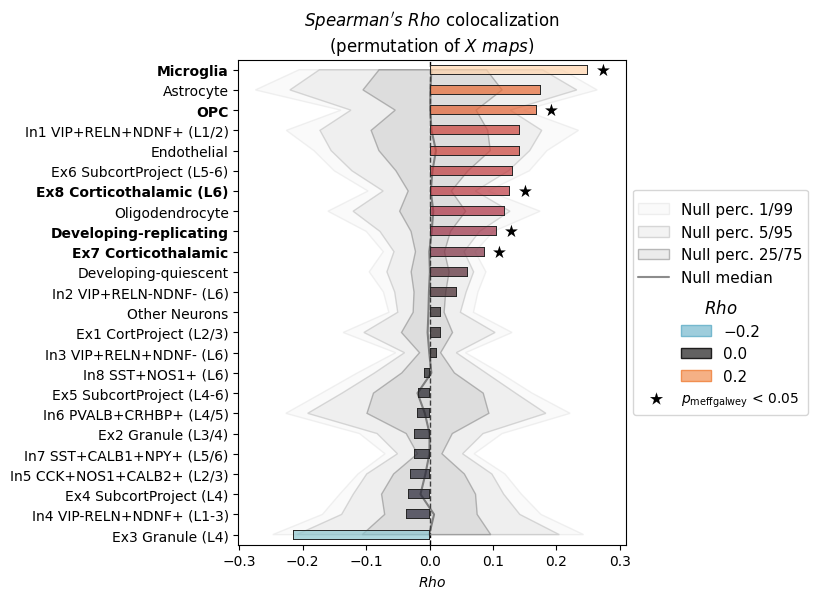

(<Figure size 500x630 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x176521100>)

In [6]:
nsp.plot(sort_by="coloc")

## XSEA with PET receptor sets

XSEA isn't limited to gene expression — you can use any reference dataset with a set structure. The PET dataset, for example, has neurotransmitter systems as sets. Running XSEA on it asks: does the pain map align more with the overall *serotonin system* than with the overall *dopamine system*, beyond what spatial autocorrelation can explain?

INFO | 01/06/26 12:44:18 | nispace.datasets: Loading pet maps.


INFO | 01/06/26 12:44:18 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 01/06/26 12:44:18 | nispace.datasets: Filtering maps by collection.


INFO | 01/06/26 12:44:18 | nispace.datasets: Filtered to 5 collection sets with between 3 and inf maps.


INFO | 01/06/26 12:44:18 | nispace.datasets: Loading and inner-merging data parcellated with 'Schaefer200Parcels7Networks' and 'TianS1'


...

INFO | 01/06/26 12:44:36 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 01/06/26 12:44:36 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 01/06/26 12:44:36 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 01/06/26 12:44:36 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 01/06/26 12:44:36 | nispace.plotting: Significance annotation: 0/5 p_uncorrected < 0.05, 0/5 p_meffgalwey < 0.05


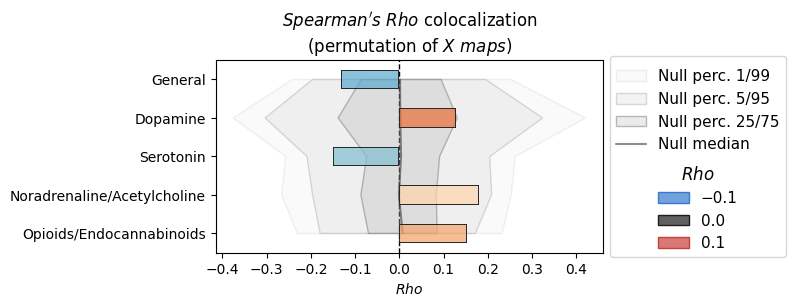

(<Figure size 500x250 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x1767d4520>)

In [7]:
# For XSEA with PET, we need a collection with the set structure (neurotransmitter
# systems as sets). UniqueTracers is a JSON-format collection that gives a two-level
# ['set', 'map'] MultiIndex — exactly what XSEA needs to aggregate by system.
pet_unique = fetch_reference(
    "pet", parcellation="Schaefer200TianS1", collection="UniqueTracers", print_references=False,
    set_size_range=(3, None) # when fetching set-based collections, some more parameters can be adjusted
) 

nsp_pet = NiSpace(
    x=pet_unique,
    y=pain_map,
    y_labels="Pain",
    parcellation="Schaefer200TianS1",
    seed=42,
    n_proc=4
)
nsp_pet.fit()
nsp_pet.colocalize("spearman", xsea=True)
nsp_pet.permute("maps", maps_which="Y", n_perm=1000, p_tails="upper")
nsp_pet.correct_p()

nsp_pet.plot()

## The `xsea_aggregation_method` parameter

By default, XSEA aggregates individual map correlations by taking the mean. Alternatively, you can use `"median"` or `"absmean"`/`"absmedian"`, or even `"weightedmean"`. The latter only works when the input dataset does have a 3-level index with `set`, `map`, and `weight` as levels.  

In practice, `"mean"` is the most common and interpretable choice, but `"absmean"` (absolute mean) can be reasonable based on the context.

INFO | 01/06/26 12:44:36 | nispace.api: *** NiSpace.colocalize() - Estimating X & Y colocalizations. ***


INFO | 01/06/26 12:44:36 | nispace.api: Running 'spearman' colocalization.


INFO | 01/06/26 12:44:36 | nispace.api: Will perform X-set enrichment analysis (XSEA).


INFO | 01/06/26 12:44:36 | nispace.api: Using 5 sets with between 3 and 6 samples. Aggregating within-set colocalizations with: absmean.


INFO | 01/06/26 12:44:36 | nispace.api: Pre-ranking X and Y data.


...

INFO | 01/06/26 12:44:39 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 01/06/26 12:44:39 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 01/06/26 12:44:39 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 01/06/26 12:44:39 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 01/06/26 12:44:39 | nispace.plotting: Significance annotation: 1/5 p_uncorrected < 0.05, 0/5 p_meffgalwey < 0.05


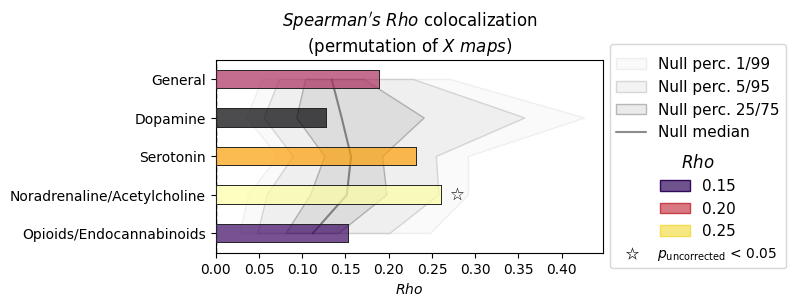

(<Figure size 500x250 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x32c05d820>)

In [8]:
# absmean aggregation
nsp_pet.colocalize("spearman", xsea=True, xsea_aggregation_method="absmean")
nsp_pet.permute("maps", maps_which="Y", n_perm=1000, p_tails="upper") # one-tailed p value in this case
nsp_pet.plot()

## XSEA via the workflow

For a one-liner version:

INFO | 01/06/26 12:44:39 | nispace.workflows: Loading integrated mrna dataset as X data.


INFO | 01/06/26 12:44:39 | nispace.datasets: Loading mrna maps.


INFO | 01/06/26 12:44:39 | nispace.datasets: Loading integrated collection 'CellTypesPsychEncodeTPM' for dataset 'mrna'.


INFO | 01/06/26 12:44:39 | nispace.datasets: Filtering maps by collection.


INFO | 01/06/26 12:44:39 | nispace.datasets: Loading and inner-merging data parcellated with 'Schaefer100Parcels7Networks' and 'TianS1'


...

INFO | 01/06/26 12:45:00 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 01/06/26 12:45:00 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


INFO | 01/06/26 12:45:00 | nispace.api: Creating categorical plot for method spearman, colocalization stat rho.


INFO | 01/06/26 12:45:00 | nispace.api: Returning z-scored colocalizations.


INFO | 01/06/26 12:45:00 | nispace.plotting: Significance annotation: 5/24 p_uncorrected < 0.05, 4/24 p_meffgalwey < 0.05


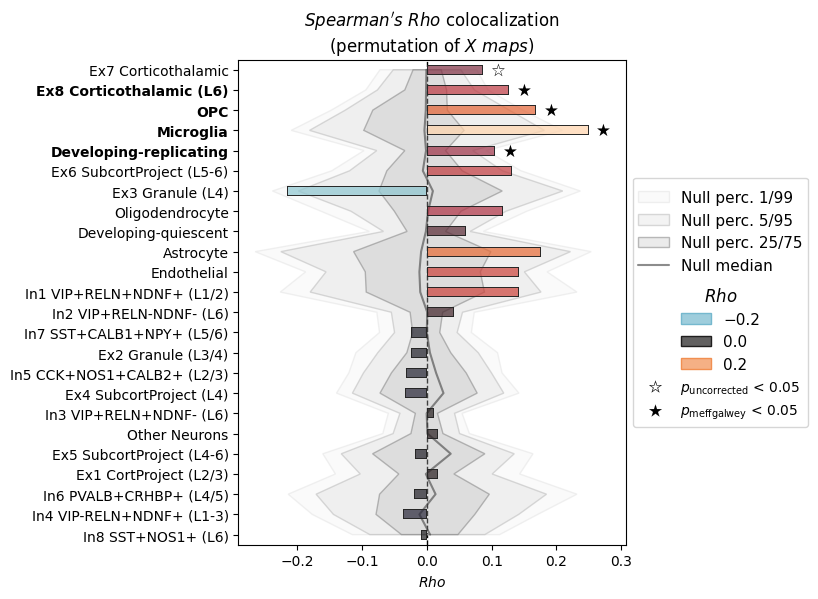

INFO | 01/06/26 12:45:01 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 


INFO | 01/06/26 12:45:01 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | None      | False       | False       | 


INFO | 01/06/26 12:45:01 | nispace.api: Returning p values: 
| METHOD   | PERMUTE_WHAT | XSEA | MC_METHOD  | X_REDUCTION | Y_TRANSFORM | 
| spearman | ymaps        | True | meffgalwey | False       | False       | 


In [9]:
from nispace.workflows import simple_xsea

nsp_wf = simple_xsea(
    y={"Pain": pain_map},
    x="mrna",
    x_collection="CellTypesPsychEncodeTPM",
    parcellation="Schaefer100TianS1",
    colocalization_method="spearman",
    n_perm=1000,
    seed=42,
    n_proc=4,
    return_nispace_only=True
)

## Summary

- XSEA aggregates individual map colocalizations within predefined sets and tests the set-level mean.
- Enable it by passing `xsea="mean"` (or `"median"`) to `colocalize()`.
- Permutation testing works the same as for individual maps: `permute("maps")`.
- The default null model (map permutation) avoids inflation from within-set co-expression, following Fulcher et al. (2021).
- ABAnnotate (the predecessor toolbox) used the same approach — XSEA in NiSpace is the generalized, multi-dataset version.
- For the workflow version: `simple_xsea()`.

Next: [Notebook 11](intro11_advanced.ipynb) covers advanced topics: dimensionality reduction, multi-modal parcellations, alternative colocalization methods, and individual-level analyses.